In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
sns.set_theme()

In [2]:
df = pd.read_csv(
    r'C:\Fause\Programas\EngSoft\repos\ML-Transportes\PBIC\Etapa3\acidentes_pbic_2020_2025_Final.csv',
    encoding='utf-8',
    parse_dates=['data_inversa'],
    dayfirst=True,
    low_memory=False
)

print("Shape inicial:", df.shape)


Shape inicial: (1678326, 48)


In [3]:
df["severity_index"] = (
    4 * df["mortos"] +
    2 * df["feridos_graves"] +
    1 * df["feridos_leves"]
)

In [4]:
df["km"] = pd.to_numeric(df["km"], errors="coerce")

df = df.dropna(subset=["km"])

In [5]:
df["km_bin"] = (df["km"] // 5) * 5   # segmentos de 5 km

In [6]:
import numpy as np

df_segmento = df.groupby(["br", "km_bin"]).agg({
    "severity_index": "mean",
    "id": "count"
}).reset_index()

df_segmento.rename(columns={"id": "n_acidentes"}, inplace=True)

In [7]:
df_segmento["score_risco"] = ( df_segmento["severity_index"] * np.log1p(df_segmento["n_acidentes"]))

In [8]:
df_segmento = df_segmento.sort_values("score_risco", ascending=False)

df_segmento.head(20)

,br,km_bin,severity_index,n_acidentes,score_risco
2685,230.0,510.0,2.443350,203,12.994027
7048,472.0,525.0,3.612903,31,12.521368
4213,293.0,110.0,3.562500,32,12.456308
6002,392.0,200.0,2.937500,64,12.262263
4970,361.0,30.0,4.000000,20,12.178090
4833,349.0,885.0,3.000000,54,12.022000
697,70.0,660.0,3.323529,34,11.816304
5270,365.0,215.0,3.650000,20,11.112507
5419,367.0,135.0,4.000000,15,11.090355
5334,365.0,535.0,3.307692,26,10.901614


In [9]:
df["severity_log"] = np.log1p(df["severity_index"])

In [10]:
df = df[df["severity_index"] >= 0]

In [11]:
features = [
    "uf",
    "br",
    "km",
    "hora",
    "mes",
    "dia_semana",
    "tipo_acidente",
    "fase_dia",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo", #*
    "tipo_veiculo",
    "idade",
    "ano_fabricacao_veiculo",
    'latitude', 
    'longitude',
    'regional', 
    'Fabricante',
    'Modelo'
]

In [12]:
df = df.dropna(subset=["severity_log"])

for col in features:
    
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
        
    else:
        df[col] = df[col].fillna("Desconhecido")

In [13]:
categoricas = df[features].select_dtypes(include="object").columns

for col in categoricas:
    df[col] = df[col].astype("category")

C:\Users\fause\AppData\Local\Temp\ipykernel_22380\1339650400.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df[features].select_dtypes(include="object").columns


In [14]:
X = df[features]
y = df["severity_log"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [16]:
import lightgbm as lgb

modelo = lgb.LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train, y_train)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035466 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 42806
[LightGBM] [Info] Number of data points in the train set: 776085, number of used features: 20
[LightGBM] [Info] Start training from score 0.421718


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.05
,n_estimators,400
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


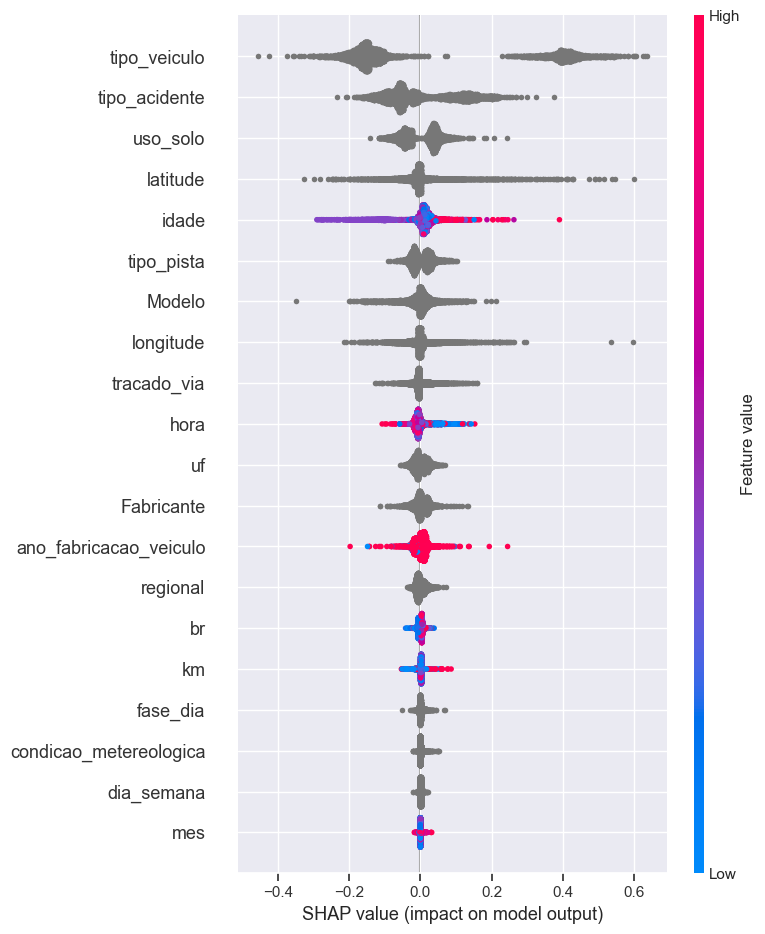

In [17]:
import shap
import numpy as np

# pegar amostra aleatória pequena
X_sample = X_test.sample(5000, random_state=42)

explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

In [18]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

pred = modelo.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.3015442464688696
R2: 0.6028048950134677


In [19]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": modelo.feature_importances_
}).sort_values("importance", ascending=False)

print(importances)

                   feature  importance
15                latitude        8840
16               longitude        6023
19                  Modelo        3928
10             tracado_via         937
13                   idade         870
18              Fabricante         770
6            tipo_acidente         596
12            tipo_veiculo         547
14  ano_fabricacao_veiculo         471
17                regional         414
3                     hora         345
2                       km         339
0                       uf         322
1                       br         221
11                uso_solo         147
4                      mes         138
9               tipo_pista         112
5               dia_semana          98
8   condicao_metereologica          41
7                 fase_dia          41


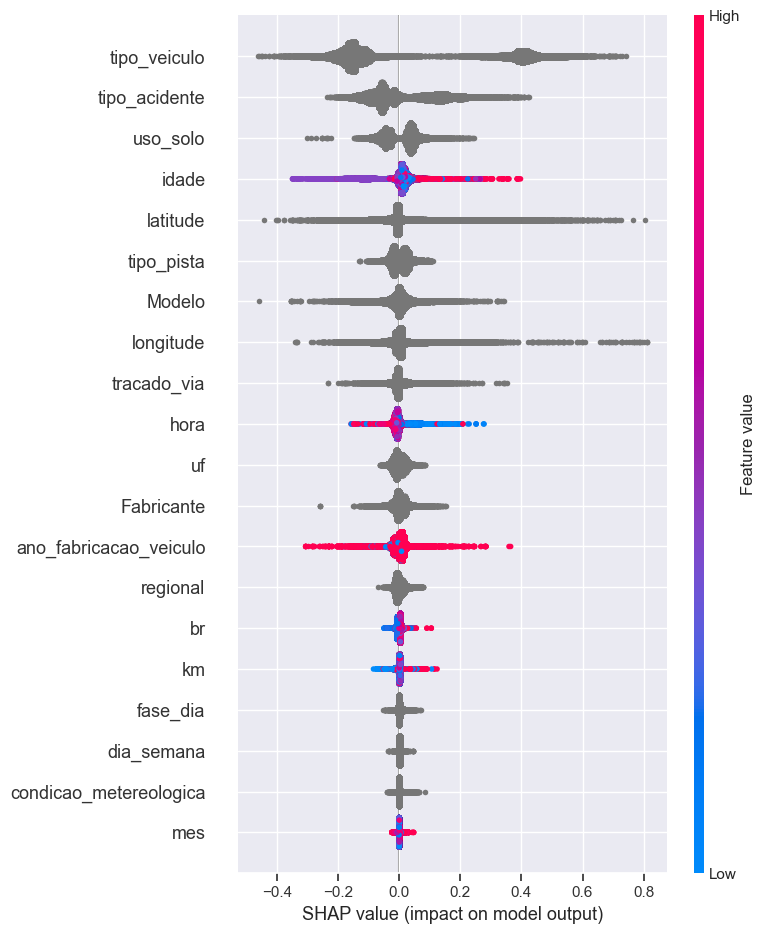

In [20]:
import shap

explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [21]:
print("\nSeveridade média por fase do dia:")
print(df.groupby("fase_dia")["severity_index"].mean())

print("\nSeveridade média por tipo de pista:")
print(df.groupby("tipo_pista")["severity_index"].mean())

print("\nSeveridade média por condição meteorológica:")
print(df.groupby("condicao_metereologica")["severity_index"].mean())

print("\nTop 10 tipos de acidente mais severos:")
print(
    df.groupby("tipo_acidente")["severity_index"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)


Severidade média por fase do dia:
fase_dia
Amanhecer      0.854587
Anoitecer      0.703058
Plena Noite    0.804683
Pleno dia      0.676473
Name: severity_index, dtype: float64

Severidade média por tipo de pista:
tipo_pista
Dupla       0.617215
Múltipla    0.563732
Simples     0.855256
Name: severity_index, dtype: float64

Severidade média por condição meteorológica:
condicao_metereologica
Chuva               0.705000
Céu Claro           0.742509
Garoa/Chuvisco      0.636143
Granizo             0.476190
Ignorado            0.909277
Neve                0.500000
Nevoeiro/Neblina    0.821965
Nublado             0.710041
Sol                 0.692160
Vento               0.563662
Name: severity_index, dtype: float64

Top 10 tipos de acidente mais severos:
tipo_acidente
Colisão frontal                 1.083817
Atropelamento de Animal         0.951968
Capotamento                     0.920305
Queda de ocupante de veículo    0.901276
Tombamento                      0.882422
Derramamento de carg

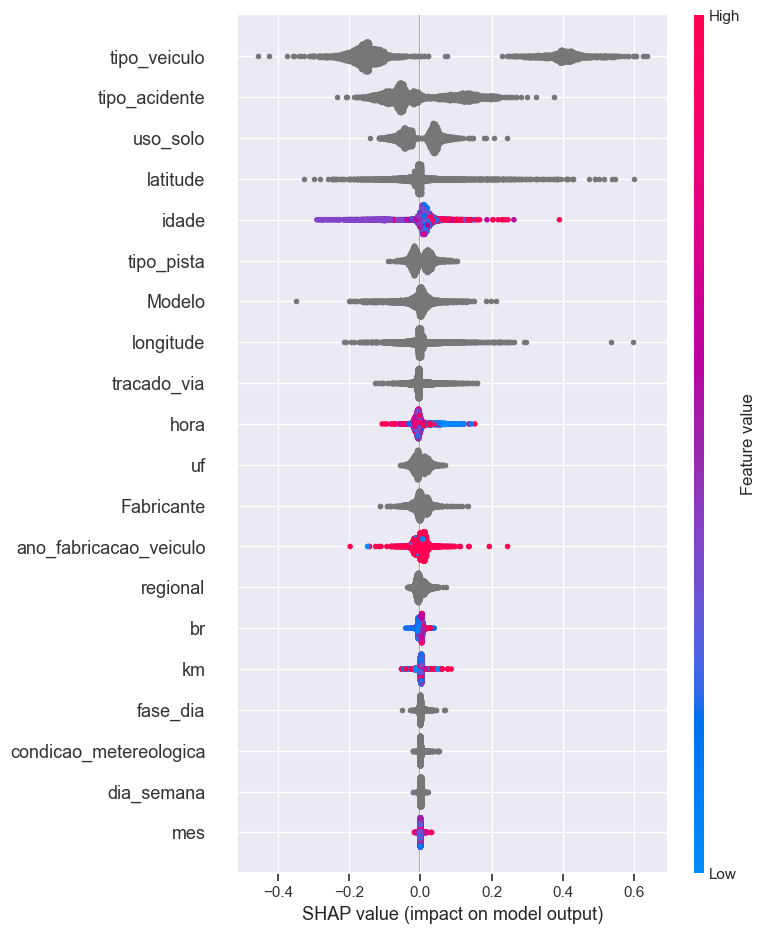

In [22]:
import shap
explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_sample)
shap.summary_plot(shap_values, X_sample)

In [23]:
df_segmento["score_risco"] = df_segmento["severity_index"] * np.log1p(df_segmento["n_acidentes"])

In [24]:
df_segmento = df_segmento.sort_values("score_risco", ascending=False)
df_segmento.head(20)

,br,km_bin,severity_index,n_acidentes,score_risco
2685,230.0,510.0,2.443350,203,12.994027
7048,472.0,525.0,3.612903,31,12.521368
4213,293.0,110.0,3.562500,32,12.456308
6002,392.0,200.0,2.937500,64,12.262263
4970,361.0,30.0,4.000000,20,12.178090
4833,349.0,885.0,3.000000,54,12.022000
697,70.0,660.0,3.323529,34,11.816304
5270,365.0,215.0,3.650000,20,11.112507
5419,367.0,135.0,4.000000,15,11.090355
5334,365.0,535.0,3.307692,26,10.901614


In [25]:
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df = df.dropna(subset=["latitude", "longitude"])  # remove linhas inválidas

In [26]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster

# =============================
# 1️⃣ Preparar dados
# =============================

# Converter latitude/longitude para float
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

# Remover linhas sem coordenadas
df = df.dropna(subset=["latitude", "longitude"])

# Criar um índice de severidade inspirado no iGLAAD
df["severity_index"] = (
    4 * df["mortos"] +
    2 * df["feridos_graves"] +
    1 * df["feridos_leves"]
)

# =============================
# 2️⃣ Criar segmentos de km
# =============================
# Segmentos de 5 km (ajustável)
df["km_bin"] = (df["km"] // 5) * 5

# =============================
# 3️⃣ Agregar por segmento
# =============================
df_segmento = df.groupby(["br", "km_bin"]).agg(
    severity_index=("severity_index", "mean"),
    n_acidentes=("severity_index", "count")
).reset_index()

# Criar um score de risco simples: severidade média * sqrt(n_acidentes)
df_segmento["score_risco"] = df_segmento["severity_index"] * np.sqrt(df_segmento["n_acidentes"])

# Ordenar por risco
df_segmento = df_segmento.sort_values("score_risco", ascending=False)

# =============================
# 4️⃣ Criar mapa interativo
# =============================

# Mapa centrado
m = folium.Map(
    location=[df["latitude"].mean(), df["longitude"].mean()],
    zoom_start=6
)

# Criar clusters de hotspots
cluster = MarkerCluster().add_to(m)

for idx, row in df_segmento.iterrows():
    # pegar acidentes do segmento
    segment = df[
        (df["br"] == row["br"]) & 
        (df["km_bin"] == row["km_bin"]) & 
        (~df["latitude"].isna()) & 
        (~df["longitude"].isna())
    ]
    
    if segment.empty:
        continue
    
    lat = segment["latitude"].mean()
    lon = segment["longitude"].mean()
    
    if np.isnan(lat) or np.isnan(lon):
        continue
    
    # Definir cor do hotspot
    if row["score_risco"] < 5:
        color = "green"
    elif row["score_risco"] < 10:
        color = "orange"
    else:
        color = "red"
    
    # Popup com informações
    popup_text = f"""
    <b>Rodovia:</b> {row['br']}<br>
    <b>Segmento (km):</b> {row['km_bin']}<br>
    <b>Severidade média:</b> {row['severity_index']:.2f}<br>
    <b>Número de acidentes:</b> {row['n_acidentes']}<br>
    <b>Score de risco:</b> {row['score_risco']:.2f}
    """
    
    folium.Circle(
        location=[lat, lon],
        radius=row["score_risco"]*50,  # tamanho proporcional ao risco
        color=color,
        fill=True,
        fill_opacity=0.6,
        popup=folium.Popup(popup_text, max_width=300)
    ).add_to(cluster)

# =============================
# 5️⃣ Salvar mapa
# =============================
m.save("mapa_risco_rodovias_interativo.html")
print("Mapa salvo como mapa_risco_rodovias_interativo.html")

Mapa salvo como mapa_risco_rodovias_interativo.html


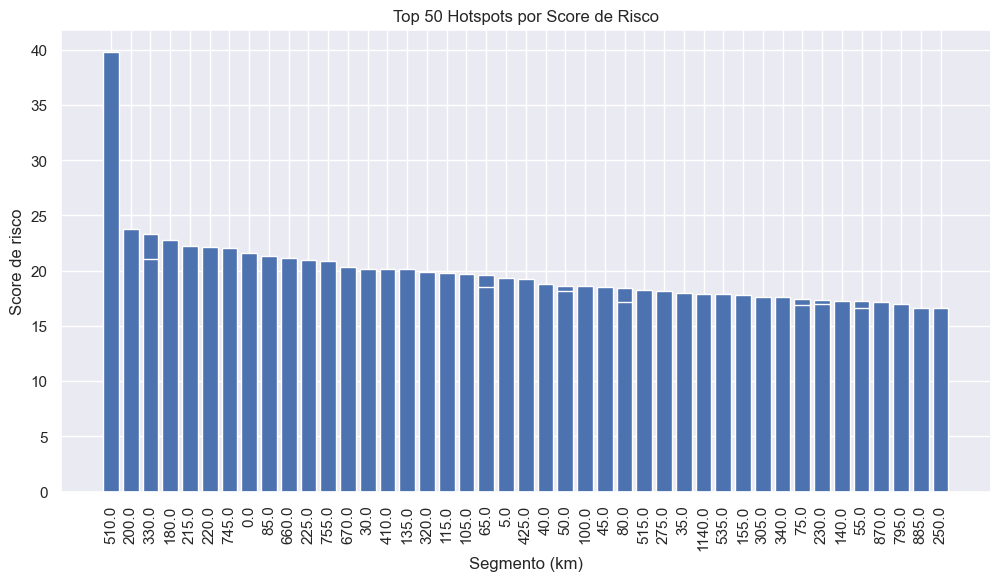

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(df_segmento["km_bin"].astype(str).head(50), df_segmento["score_risco"].head(50))
plt.xticks(rotation=90)
plt.ylabel("Score de risco")
plt.xlabel("Segmento (km)")
plt.title("Top 50 Hotspots por Score de Risco")
plt.show()

In [28]:
df_norm = df[["mortos","feridos_graves","feridos_leves"]] / df[["mortos","feridos_graves","feridos_leves"]].max()

In [29]:
from scipy.optimize import minimize
import numpy as np

# Função de erro inversa do R2 (queremos maximizar R2)
def f_obj(p):
    severity_pred = p[0]*df["mortos"] + p[1]*df["feridos_graves"] + p[2]*df["feridos_leves"]
    r2 = np.corrcoef(severity_pred, df["total_vitimas"])[0,1]**2
    return -r2  # negativo porque o minimizador minimiza

res = minimize(f_obj, x0=[1,1,1], bounds=[(0,10),(0,10),(0,10)])
print("Pesos ótimos:", res.x)

Pesos ótimos: [1. 1. 1.]


In [30]:
from sklearn.linear_model import LinearRegression

X = df[["mortos","feridos_graves","feridos_leves"]]
y = df["total_vitimas"]  # ou outra proxy de severidade
model = LinearRegression().fit(X, y)
print("Pesos aprendidos:", model.coef_)

Pesos aprendidos: [0.12798707 0.12798707 0.12798707]
